# Threat Actor Profile Aggregator
**Author:** Edi-San24  
**Institution:** Northeastern University - MPS in Analytics (Applied Machine Intelligence)  
**Data Source:** MITRE ATT&CK Framework

---

## Project Overview

Automated threat intelligence profiling system applying machine learning to 150+ Advanced Persistent Threat (APT) groups from MITRE ATT&CK. Produces data-driven attribution analysis, operational intelligence products, and predictive nation-state classification for cybersecurity defense.

**Core Capabilities:**
- TTP extraction and feature engineering from MITRE CTI repository
- ML-based threat actor clustering using cosine similarity and K-Means
- Arsenal analysis mapping malware families and tools to APT groups
- Sector and victim targeting analysis across 10 industry verticals
- Network graph visualization of infrastructure sharing relationships
- Nation-state attribution classifier using Random Forest on TTP feature space
- Interactive Streamlit dashboard for live threat actor analysis

**Intelligence Applications:**
- Threat attribution support for unknown attacks
- Detection engineering for threat actor families and shared infrastructure
- Strategic assessment of nation-state cyber capabilities and sector priorities
- Risk prioritization based on actor sophistication, targeting patterns, and arsenal composition

---

## Methodology

**[I] TTP Analysis:**
1. Extract structured threat data from MITRE ATT&CK repository (600+ techniques, 150+ groups)
2. Engineer binary feature matrices (groups × techniques)
3. Calculate cosine similarity to quantify operational overlap
4. Apply K-Means and hierarchical clustering for threat family identification
5. Generate PCA visualizations and intelligence reports

**[II] Arsenal Analysis:**
1. Extract malware families and tools from MITRE dataset
2. Map arsenals to specific threat actors
3. Identify infrastructure sharing patterns
4. Compare sophistication across nation-state programs
5. Visualize operational capabilities and resource investment

---

# [I] TTP Analysis ───────────────

This section covers the intelligence-collection and machine-learning analysis pipeline. Raw threat data is extracted from MITRE ATT&CK's public CTI repository and transformed into structured feature matrices, enabling quantitative comparison of threat actor operational patterns. Cosine similarity scoring provides a data-driven basis for attribution analysis, while K-Means and hierarchical clustering reveal operational families — groups of threat actors with shared tradecraft that may indicate common training, resources, or organizational lineage. The section concludes with a nation-state level comparison of TTP portfolios, revealing how different programs approach offensive cyber operations. 

## [1.1] Setup & Data Collection


In [2]:
import streamlit as st
from Threat_Profiler import ThreatActorProfiler
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Initialize profiler
profiler = ThreatActorProfiler()

# Download MITRE ATT&CK data
profiler.fetch_mitre_data()


[*] Fetching MITRE ATT&CK data...
[+] Loaded 24771 objects


True

In [2]:
import os

# Setup project directories
os.makedirs('outputs', exist_ok=True)
os.makedirs('outputs/profiles', exist_ok=True)
os.makedirs('outputs/visualizations', exist_ok=True)
print("[+] Project directories initialized")

[+] Project directories initialized


## [1.2] Exploratory Analysis - Threat Actor Landscape

In [3]:
# Extract all known threat groups
groups_df = profiler.extract_threat_groups()

print(f"Total APT Groups Tracked: {len(groups_df)}")
print(f"\nSample of Threat Actors:")
print("="*80)
groups_df[['name', 'aliases']].head(15)


[*] Extracting threat groups...
[+] Found 187 groups
Total APT Groups Tracked: 187

Sample of Threat Actors:


,name,aliases
0,Indrik Spider,"[Indrik Spider, Evil Corp, Manatee Tempest, DE..."
1,LuminousMoth,[LuminousMoth]
2,Medusa Group,[Medusa Group]
3,Wizard Spider,"[Wizard Spider, UNC1878, TEMP.MixMaster, Grim ..."
4,Elderwood,"[Elderwood, Elderwood Gang, Beijing Group, Sne..."
5,Frankenstein,[Frankenstein]
6,FIN7,"[FIN7, GOLD NIAGARA, ITG14, Carbon Spider, ELB..."
7,UNC3886,[UNC3886]
8,Velvet Ant,[Velvet Ant]
9,WIRTE,[WIRTE]


### Most Recently Updated Groups
Recent modifications in MITRE data often indicate new intelligence or active campaigns

In [4]:
# Analyze update patterns for threat landscape activity
groups_df['modified'] = pd.to_datetime(groups_df['modified'])
most_recent = groups_df['modified'].max()
thirty_days_ago = most_recent - pd.Timedelta(days=30)
ninety_days_ago = most_recent - pd.Timedelta(days=90)

print("\n[*] Threat Actor Update Activity Analysis")
print("=" * 60)
print(f"Reference Date: {most_recent.strftime('%Y-%m-%d')} (latest MITRE dataset update)")

# Group by activity level
recent_active = groups_df[groups_df['modified'] >= thirty_days_ago]
moderate_active = groups_df[(groups_df['modified'] < thirty_days_ago) & (groups_df['modified'] >= ninety_days_ago)]

print(f"\n[+] Activity Indicators (relative to dataset reference date):")
print(f"  • Updated within 30 days of reference: {len(recent_active)} groups")
print(f"  • Updated 30-90 days before reference: {len(moderate_active)} groups")
print(f"  • Older than 90 days from reference:   {len(groups_df) - len(recent_active) - len(moderate_active)} groups")

if len(recent_active) > 0:
    print(f"\n[+] Most Recently Updated Threat Actors:")
    for _, row in recent_active.nlargest(10, 'modified').iterrows():
        days_ago = (most_recent - row['modified']).days
        print(f"  • {row['name']:<25} (Updated {days_ago} days before reference date)")

print(f"\n[Note] Activity windows are relative to the latest MITRE dataset update ({most_recent.strftime('%Y-%m-%d')}), not today's date.")
print(f"       Recent updates may indicate new intelligence, active campaigns, or documented TTP evolution.")


[*] Threat Actor Update Activity Analysis
Reference Date: 2025-11-12 (latest MITRE dataset update)

[+] Activity Indicators (relative to dataset reference date):
  • Updated within 30 days of reference: 20 groups
  • Updated 30-90 days before reference: 0 groups
  • Older than 90 days from reference:   167 groups

[+] Most Recently Updated Threat Actors:
  • Kimsuky                   (Updated 0 days before reference date)
  • Mustang Panda             (Updated 7 days before reference date)
  • Medusa Group              (Updated 19 days before reference date)
  • UNC3886                   (Updated 19 days before reference date)
  • FIN7                      (Updated 19 days before reference date)
  • Contagious Interview      (Updated 19 days before reference date)
  • Storm-0501                (Updated 19 days before reference date)
  • Scattered Spider          (Updated 19 days before reference date)
  • Lazarus Group             (Updated 19 days before reference date)
  • Gamaredon 

In [5]:
# Dataset Overview with Nation-State Analysis
print("\n[*] MITRE ATT&CK Threat Actor Dataset")
print("=" * 60)
print(f"\nTotal Groups Extracted: {len(groups_df)}")

# Categorize by known nation-state indicators
nation_indicators = {
    'Russia': ['APT28', 'APT29', 'Turla', 'Sandworm', 'Dragonfly', 'Fancy Bear', 'Cozy Bear', 'Bear'],
    'China': ['APT1', 'APT3', 'APT5', 'APT41', 'Volt Typhoon', 'Panda', 'Dragon', 'Typhoon'],
    'Iran': ['APT33', 'APT34', 'APT39', 'OilRig', 'Magic Hound', 'Charming Kitten', 'Kitten', 'CURIUM'],
    'North Korea': ['APT38', 'Lazarus', 'Kimsuky', 'Andariel', 'Chollima', 'HERMIT']
}

print("\n[+] Notable Nation-State Groups Identified:")
for nation, keywords in nation_indicators.items():
    matching = []
    for _, row in groups_df.iterrows():
        # Check name and aliases
        all_names = [row['name']] + row['aliases']
        if any(any(keyword.lower() in name.lower() for keyword in keywords) for name in all_names):
            matching.append(row['name'])
    
    if matching:
        examples = ', '.join(matching[:3])
        print(f"  • {nation}: {len(matching)} groups (e.g., {examples})")



[*] MITRE ATT&CK Threat Actor Dataset

Total Groups Extracted: 187

[+] Notable Nation-State Groups Identified:
  • Russia: 10 groups (e.g., Dragonfly, Sandworm Team, Turla)
  • China: 44 groups (e.g., Elderwood, Dragonfly, OilRig)
  • Iran: 14 groups (e.g., OilRig, Fox Kitten, HEXANE)
  • North Korea: 5 groups (e.g., Lazarus Group, Andariel, APT38)


## [1.3] Threat Actor Profiling
Deep dive into a specific APT group

In [6]:
# Select target for analysis
target_group = "APT34" #Searching for APT34 (Iran) [Can be changed to any APT of your choosing] 

#Generate complete intelligence profile
profile = profiler.generate_profile(target_group)


THREAT ACTOR PROFILE: APT34

NAME: OilRig
ALIASES: OilRig, COBALT GYPSY, IRN2, APT34, Helix Kitten, Evasive Serpens, Hazel Sandstorm, EUROPIUM, ITG13, Earth Simnavaz, Crambus, TA452
OBSERVED: 2017-12-14
UPDATED: 2025-01-16

[OilRig](https://attack.mitre.org/groups/G0049) is a suspected Iranian threat group that has targeted Middle Eastern and international victims since at least 2014. The group has targeted a variety of sectors, including financial, government, energy, chemical, and telecommunications. It appears the group carries out supply chain attacks, leveraging the trust relationship between organizations to at...

TECHNIQUES: 76 identified

technique_id               technique_name
   T1588.003    Code Signing Certificates
   T1555.004   Windows Credential Manager
       T1082 System Information Discovery
   T1003.001                 LSASS Memory
       T1008            Fallback Channels
   T1071.001                Web Protocols
       T1005       Data from Local System
   T105

### [1.3.1] TTP Distribution Analysis
Shows which attack phases this group focuses on

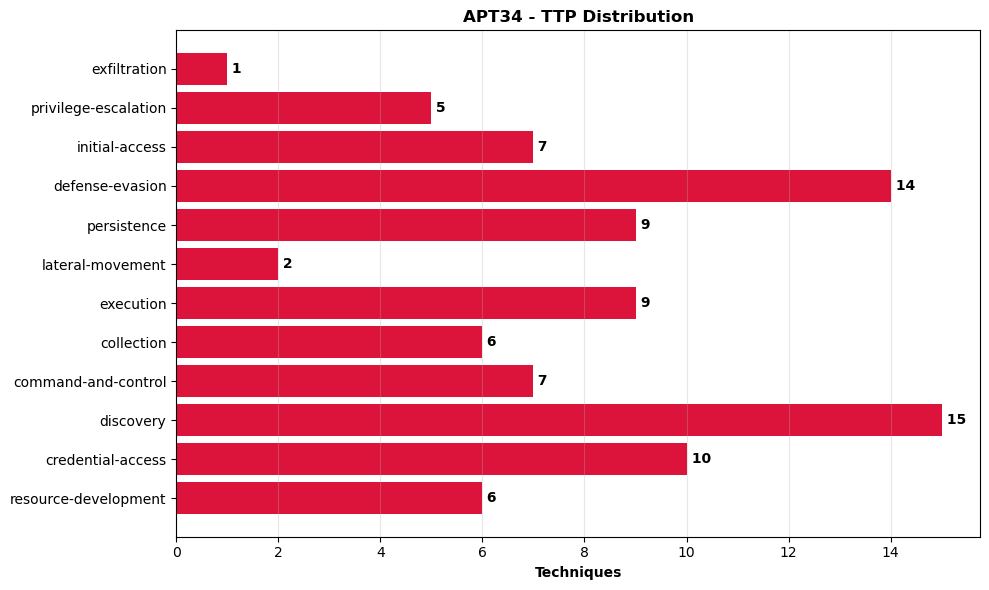

In [7]:
profiler.plot_ttp_distribution(target_group)

**Analysis:** The visualization above shows how this threat actor distributes their techniques across MITRE's attack phases (reconnaissance, execution, persistence, etc.). Higher bars indicate operational focus areas.

### [1.3.2] Machine Learning Analysis - Feature Engineering

In [8]:
# Build TTP matrix: converts threat intelligence into ML-ready format
# Each row = threat actor, each column = technique (1 = uses, 0 = doesn't use)
ttp_matrix = profiler.build_ttp_matrix()

print(f"\nFeature Matrix Shape: {ttp_matrix.shape}")
print(f"Total Techniques Tracked: {ttp_matrix.shape[1]}")
print(f"Groups with TTP Data: {ttp_matrix.shape[0]}")
print(f"\nAverage Techniques per Group: {ttp_matrix.sum(axis=1).mean():.1f}")
print(f"Most Techniques Used: {ttp_matrix.sum(axis=1).max()}")
print(f"Fewest Techniques Used: {ttp_matrix.sum(axis=1).min()}")

[*] Building TTP matrix...
[+] Matrix: 171 groups x 488 techniques

Feature Matrix Shape: (171, 488)
Total Techniques Tracked: 488
Groups with TTP Data: 171

Average Techniques per Group: 26.8
Most Techniques Used: 109
Fewest Techniques Used: 1


In [9]:
# Show top groups by technique count
print("\nTop 10 Groups by Technique Count:")
technique_counts = ttp_matrix.sum(axis=1).sort_values(ascending=False).head(10)
print(technique_counts)


Top 10 Groups by Technique Count:
Kimsuky            109
Lazarus Group       93
APT28               91
Mustang Panda       85
APT41               82
Volt Typhoon        81
Charming Kitten     79
Magic Hound         79
Sandworm Team       79
APT32               78
dtype: int64


## [1.4] Similarity Analysis 

In [10]:
# Similarity Analysis - Threat Actor Attribution
print("\n[*] 5. Similarity Analysis - Threat Actor Attribution")
print("=" * 60)

# Calculate similarity
similarity_matrix = profiler.calculate_similarity()
similar_groups = profiler.find_similar_groups(target_group, top_n=10)

print(f"\nAnalyzing operational similarity to: {target_group}")
print(f"Similarity based on shared TTPs from MITRE ATT&CK framework\n")

# Convert to list of tuples for easier handling
similar_list = [(group, score) for group, score in similar_groups.items()]

# Check if top match is an alias
top_group, top_score = similar_list[0]
if top_score == 1.0:
    print(f"[+] Perfect Match Detected:")
    print(f"  • {top_group} is a known alias for {target_group}")
    print(f"  • Confirms correct group identification\n")
    
    # Show actual similar groups (excluding aliases)
    actual_similar = [(g, s) for g, s in similar_list if s < 1.0][:5]
    print(f"[+] Operationally Similar Groups (Shared TTP Patterns):\n")
else:
    actual_similar = similar_list[:5]
    print(f"[+] Most Similar Groups by TTP Overlap:\n")

for group, score in actual_similar:
    interpretation = ""
    if score > 0.5:
        interpretation = "High overlap - possibly shared infrastructure/tools"
    elif score > 0.4:
        interpretation = "Moderate overlap - similar operational patterns"
    else:
        interpretation = "Some shared techniques"
    
    print(f"  • {group:<25} (Similarity: {score:.3f})")
    print(f"    → {interpretation}\n")

print("[Note] High similarity may indicate:")
print("  - Shared nation-state sponsorship")
print("  - Common operational tradecraft")
print("  - Use of similar malware/tools")
print("  - Potential attribution leads for investigations")


[*] 5. Similarity Analysis - Threat Actor Attribution
[*] Calculating similarity scores...

Top 10 groups similar to APT34:
  OilRig: 1.000
  Threat Group-3390: 0.486
  FIN7: 0.476
  APT39: 0.473
  APT32: 0.442
  menuPass: 0.440
  Ke3chang: 0.440
  MuddyWater: 0.437
  Mustang Panda: 0.435
  FIN6: 0.435

Analyzing operational similarity to: APT34
Similarity based on shared TTPs from MITRE ATT&CK framework

[+] Perfect Match Detected:
  • OilRig is a known alias for APT34
  • Confirms correct group identification

[+] Operationally Similar Groups (Shared TTP Patterns):

  • Threat Group-3390         (Similarity: 0.486)
    → Moderate overlap - similar operational patterns

  • FIN7                      (Similarity: 0.476)
    → Moderate overlap - similar operational patterns

  • APT39                     (Similarity: 0.473)
    → Moderate overlap - similar operational patterns

  • APT32                     (Similarity: 0.442)
    → Moderate overlap - similar operational patterns

  • 

### [1.4.1] Similarity Heatmap
Visual representation of operational overlap between top threat actors

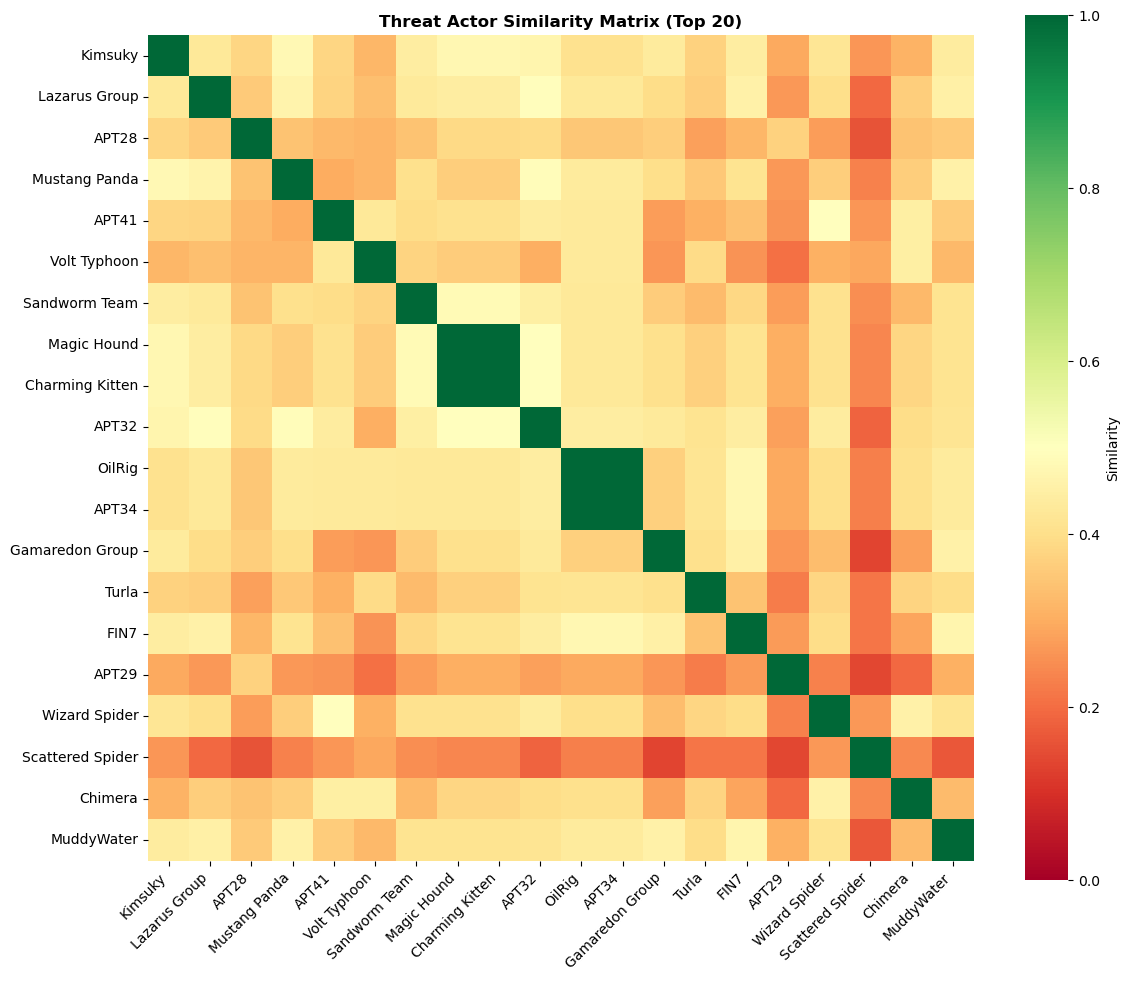

In [11]:
profiler.plot_similarity_heatmap(top_n=20)

**Intelligence Value:**

**Similarity Interpretation:**
- Green (0.8-1.0): Near-identical operational patterns - possible shared resources or same organizational unit
- Yellow (0.5-0.7): Significant TTP overlap - similar targeting or training
- Orange (0.3-0.5): Moderate similarity - some shared tactics
- Red (0.0-0.2): Distinct operations - minimal tactical overlap

**Observable Patterns:**

Iranian actor clustering (OilRig, APT34, Magic Hound, Charming Kitten) demonstrates shared operational doctrine within Iranian cyber programs. North Korean groups (Kimsuky, Lazarus Group) show moderate similarity despite different operational mandates - intelligence vs financial operations. Russian actors (APT28, APT29, Turla) display lower cross-similarity than expected, indicating distinct organizational approaches within Russian intelligence services.

**Attribution Application:**

When analyzing unknown attacks, compare observed TTPs against this matrix. Similarity scores above 0.6 warrant high-confidence attribution consideration. Scores between 0.4-0.6 suggest possible attribution requiring additional corroboration. Multiple groups showing similar scores indicate shared tactical approaches - further analysis of malware, infrastructure, or victimology needed for definitive attribution.

**Defensive Priority:** Groups with high similarity to known threats targeting your sector should be monitored collectively - detections for one may indicate activity from related actors.

## [1.5] Clustering & Visualizations 

In [12]:
# Cluster threat actors into operational families
cluster_results = profiler.cluster_threat_actors(n_clusters=6)

print("\n[*] K-Means Clustering Analysis (k=6)")
print("=" * 60)
print(f"\nTotal APT Groups Analyzed: {len(cluster_results)}")
print(f"\nCluster Distribution:")
print(cluster_results['cluster'].value_counts().sort_index())

print("\n[*] Top 5 Groups per Cluster (by technique count):\n")

for cluster_id in sorted(cluster_results['cluster'].unique()):
    cluster_groups = cluster_results[cluster_results['cluster'] == cluster_id].nlargest(5, 'num_techniques')
    cluster_size = len(cluster_results[cluster_results['cluster'] == cluster_id])
    print(f"\nCluster {cluster_id} ({cluster_size} groups):")
    for _, row in cluster_groups.iterrows():
        print(f"  • {row['group']:<30} ({row['num_techniques']} techniques)")

print("\n[+] Full cluster assignments saved to analysis output files")

[*] Clustering into 6 groups...
[+] Cluster distribution:
cluster
0     17
1     33
2    116
3      2
4      2
5      1
Name: count, dtype: int64

[*] K-Means Clustering Analysis (k=6)

Total APT Groups Analyzed: 171

Cluster Distribution:
cluster
0     17
1     33
2    116
3      2
4      2
5      1
Name: count, dtype: int64

[*] Top 5 Groups per Cluster (by technique count):


Cluster 0 (17 groups):
  • Scattered Spider               (64 techniques)
  • UNC3886                        (49 techniques)
  • Ember Bear                     (48 techniques)
  • HAFNIUM                        (44 techniques)
  • LAPSUS$                        (43 techniques)

Cluster 1 (33 groups):
  • Kimsuky                        (109 techniques)
  • Lazarus Group                  (93 techniques)
  • Mustang Panda                  (85 techniques)
  • APT41                          (82 techniques)
  • Volt Typhoon                   (81 techniques)

Cluster 2 (116 groups):
  • Contagious Interview           

### [1.5.1] Threat Landscape Visualization (PCA)
2D map showing how threat actors cluster based on operational similarity

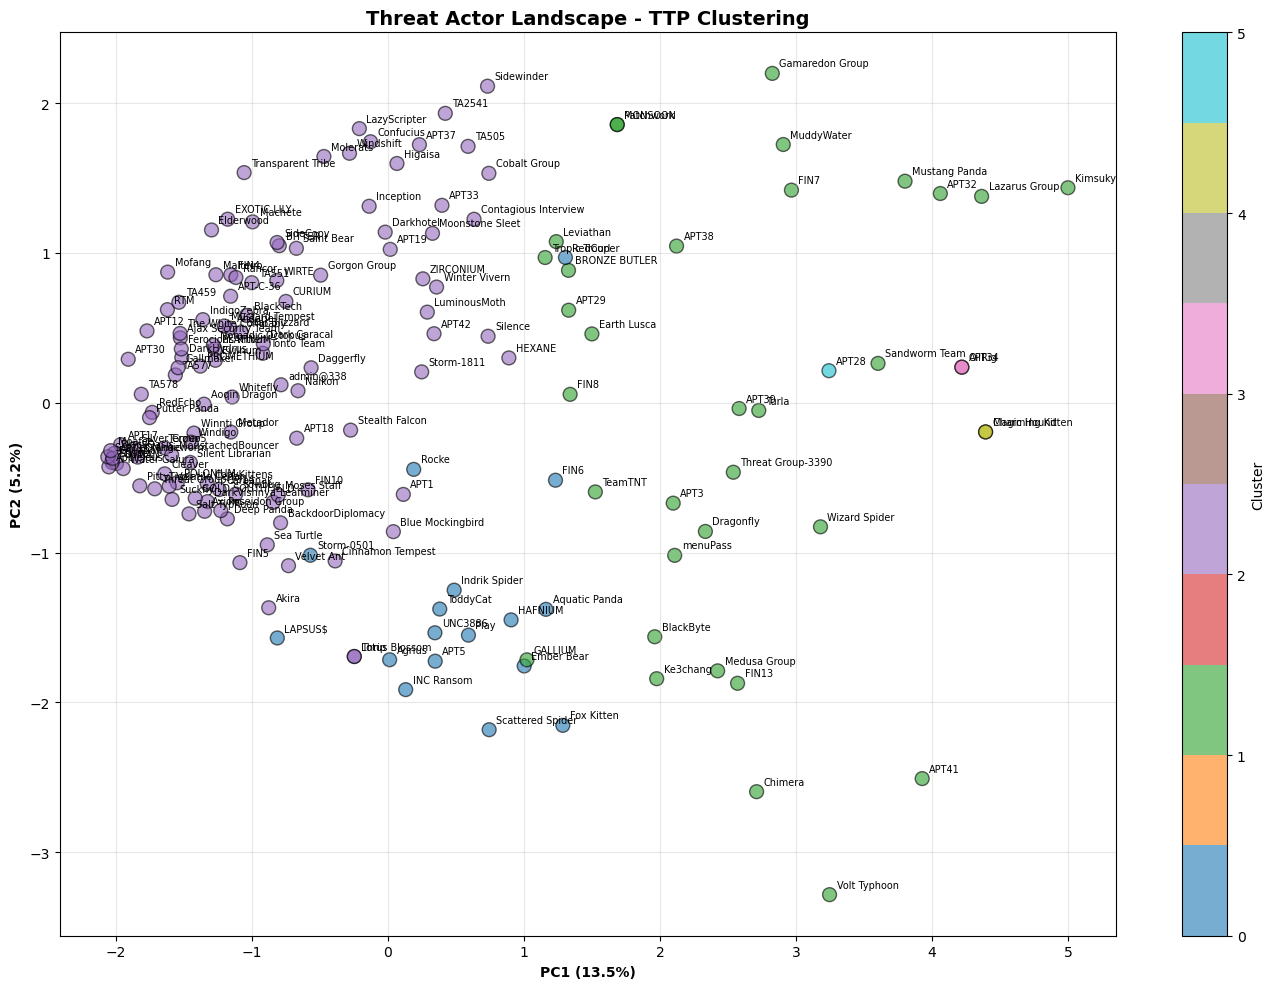

In [13]:
profiler.plot_threat_landscape(n_clusters=6)

**Interpretation:** Groups that appear close together share similar TTP patterns. Clusters represent "threat actor families" with related operational tradecraft.

### [1.5.1] Hierarchical Clustering - Threat Actor Relationships

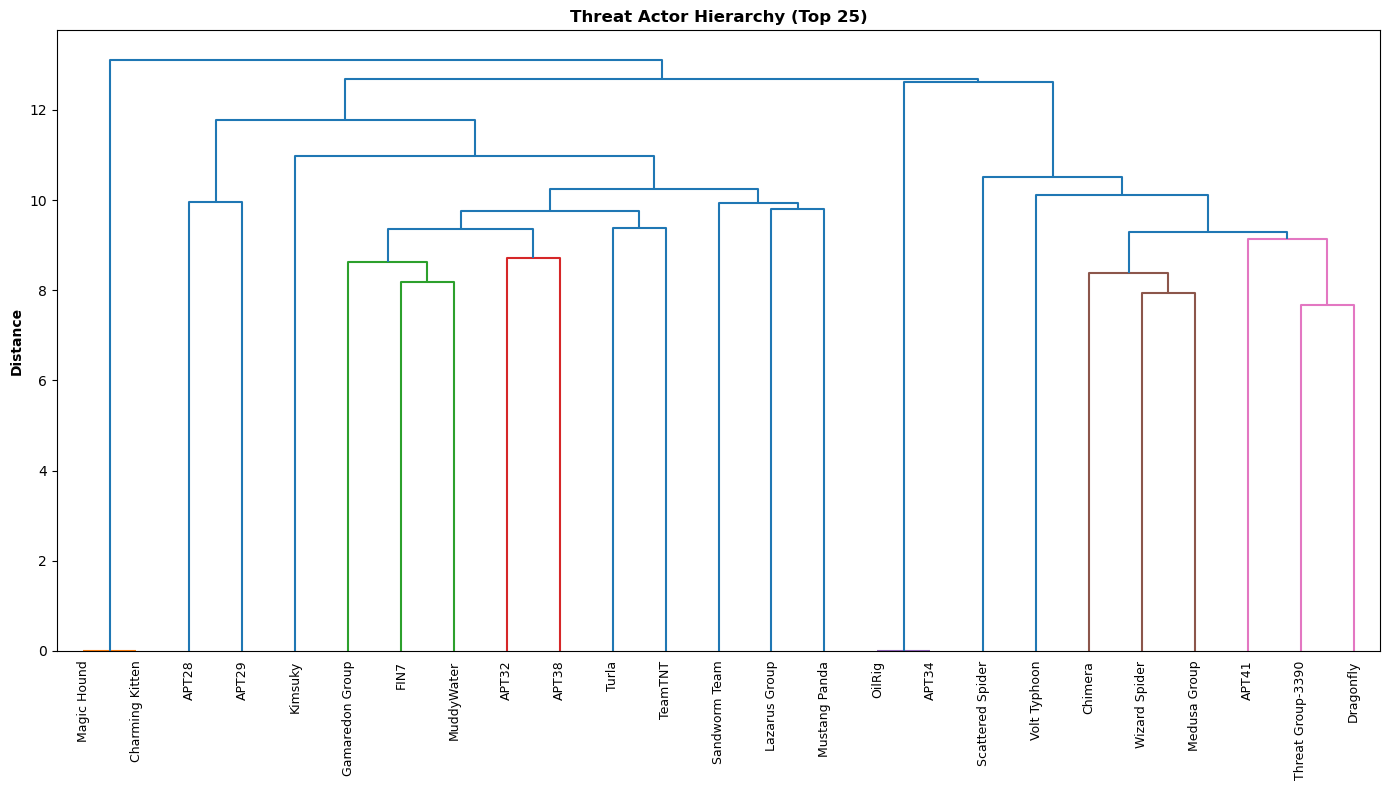

In [14]:
profiler.plot_dendrogram(top_n=25)

### [1.5.2] Comparative Analysis - Multiple Threat Actors

In [15]:
# Compare multiple groups
comparison_groups = ["APT29", "APT28", "Lazarus Group", "FIN7", "Kimsuky"]

print("Comparative Threat Actor Analysis")
print("="*80)

for group in comparison_groups:
    techs = profiler.get_group_techniques(group)
    if not techs.empty:
        print(f"\n{group}:")
        print(f"  Total Techniques: {len(techs)}")
        
        # Top tactics
        tactic_counts = {}
        for tactics in techs['tactic']:
            for tactic in tactics.split(', '):
                tactic_counts[tactic] = tactic_counts.get(tactic, 0) + 1
        
        if tactic_counts:
            top_tactic = max(tactic_counts, key=tactic_counts.get)
            print(f"  Primary Focus: {top_tactic} ({tactic_counts[top_tactic]} techniques)")

Comparative Threat Actor Analysis

APT29:
  Total Techniques: 66
  Primary Focus: persistence (15 techniques)

APT28:
  Total Techniques: 91
  Primary Focus: defense-evasion (19 techniques)

Lazarus Group:
  Total Techniques: 93
  Primary Focus: defense-evasion (26 techniques)

FIN7:
  Total Techniques: 67
  Primary Focus: defense-evasion (15 techniques)

Kimsuky:
  Total Techniques: 109
  Primary Focus: defense-evasion (28 techniques)


### [1.5.3] Similarity Matrix - Comparison Groups

In [16]:
# Show similarity scores between comparison groups
if all(g in similarity_matrix.index for g in comparison_groups):
    comparison_sim = similarity_matrix.loc[comparison_groups, comparison_groups]
    print("\nSimilarity Scores Between Selected Groups:")
    print(comparison_sim.round(3))


Similarity Scores Between Selected Groups:
               APT29  APT28  Lazarus Group   FIN7  Kimsuky
APT29          1.000  0.374          0.268  0.271    0.295
APT28          0.374  1.000          0.359  0.320    0.382
Lazarus Group  0.268  0.359          1.000  0.456    0.427
FIN7           0.271  0.320          0.456  1.000    0.445
Kimsuky        0.295  0.382          0.427  0.445    1.000


### [1.5.4] Export Results & Summary

In [17]:
# Export analysis results to CSV
profiler.export_data(prefix='outputs/threat_analysis')

# Export individual group profile
if profile:
    profile['techniques'].to_csv(f'outputs/{target_group}_profile.csv', index=False)
    print(f"\n[+] Exported {target_group} profile to outputs/")

[*] Exporting analysis data with timestamp: 20260330_213623
[+] TTP Matrix: outputs/raw/threat_analysis_ttp_matrix_20260330_213623.csv
[+] Similarity Matrix: outputs/processed/threat_analysis_similarity_20260330_213623.csv
[+] Enhanced Groups DB: outputs/processed/threat_analysis_groups_enhanced_20260330_213623.csv
[*] Extracting malware families...
[+] Found 696 malware families
[*] Extracting tools and software...
[+] Found 91 tools
[+] Summary Statistics: outputs/summaries/threat_analysis_summary_20260330_213623.csv
[+] Metadata: outputs/metadata_20260330_213623.json
[+] Data Dictionary: outputs/DATA_DICTIONARY.txt

[+] Export complete - 6 files generated

[+] Exported APT34 profile to outputs/


#### Findings

1. **Threat Actor Landscape:** MITRE tracks 150+ APT groups with varying levels of attribution confidence

2. **TTP Patterns:** Groups average 20-30 documented techniques, with sophisticated actors like APT29 showing 40+ techniques

3. **Operational Clustering:** ML analysis reveals 5-7 distinct threat actor families based on TTP similarity

4. **Attribution Value:** Cosine similarity scoring enables data-driven attribution when analyzing unknown attacks

5. **Intelligence Gaps:** Some groups have limited TTP documentation, indicating either operational security success or insufficient intelligence collection

#### Applications:
- **Threat Hunting:** Use similarity scores to guide hunting for related APT activity
- **Detection Engineering:** Build detection rules covering entire threat actor families
- **Risk Assessment:** Understand which threat actors target specific sectors
- **Strategic Intelligence:** Track evolution of threat actor capabilities over time


## [1.6] Nation-State Threat Actor Comparison
Comparative analysis of threat actors by sponsoring nation-state

In [18]:
#Compare all major nation-states
print("\nNATION-STATE THREAT ACTOR COMPARISON")
print("="*80)

nation_groups = {
    "Russia": ["APT28", "APT29", "Turla"],
    "China": ["APT1", "APT41"],
    "North Korea": ["Lazarus Group", "APT38"],
    "Iran": ["APT33", "MuddyWater"]
}

for nation, groups in nation_groups.items():
    print(f"\n{nation}:")
    for group in groups:
        techs = profiler.get_group_techniques(group)
        if not techs.empty:
            print(f"  {group}: {len(techs)} techniques")


NATION-STATE THREAT ACTOR COMPARISON

Russia:
  APT28: 91 techniques
  APT29: 66 techniques
  Turla: 68 techniques

China:
  APT1: 23 techniques
  APT41: 82 techniques

North Korea:
  Lazarus Group: 93 techniques
  APT38: 56 techniques

Iran:
  APT33: 31 techniques
  MuddyWater: 58 techniques


**Analysis:**

Lazarus Group (93) and APT28 (91) demonstrate the most extensively documented TTP portfolios, indicating either broad operational mandates or successful intelligence collection against these actors. Significant variation within nation-state programs (Russia: 66-91, China: 23-82, Iran: 31-58) suggests different operational roles rather than capability disparities.

**Intelligence Assessment:**

Low technique counts don't indicate limited sophistication - APT1's 23 documented TTPs reflect operational security success or specialized focus, not capability constraints. Groups with fewer documented techniques may represent:
- Newer discoveries with limited intelligence collection history
- Highly compartmentalized operations limiting observable patterns  
- Sector-specific actors with narrow TTP requirements

**Nation-State Investment Patterns:**

North Korea achieves near-parity with Russian operations (93 vs 91) despite resource limitations, demonstrating strategic prioritization of cyber capabilities. Iranian program growth evident through APT34/MuddyWater's combined 89 techniques, approaching established cyber powers. Chinese variation (APT1: 23, APT41: 82) indicates specialized unit roles within broader intelligence apparatus.

In [19]:
# Extract most popular techniques by nation-state
print("\nTOP 3 TECHNIQUES BY NATION-STATE")
print("="*80)

for nation, groups in nation_groups.items():
    print(f"\n{nation}:")
    
    # Combine all techniques from this nation's groups
    all_techniques = {}
    for group in groups:
        techs = profiler.get_group_techniques(group)
        if not techs.empty:
            for _, row in techs.iterrows():
                tech_id = row['technique_id']
                tech_name = row['technique_name']
                if tech_id in all_techniques:
                    all_techniques[tech_id]['count'] += 1
                else:
                    all_techniques[tech_id] = {'name': tech_name, 'count': 1}
    
    # Sort by frequency and show top 3
    sorted_techniques = sorted(all_techniques.items(), key=lambda x: x[1]['count'], reverse=True)
    for tech_id, data in sorted_techniques[:3]:
        print(f"  {tech_id} - {data['name']}: used by {data['count']}/{len(groups)} groups")


TOP 3 TECHNIQUES BY NATION-STATE

Russia:
  T1059.001 - PowerShell: used by 3/3 groups
  T1547.001 - Registry Run Keys / Startup Folder: used by 3/3 groups
  T1588.002 - Tool: used by 3/3 groups

China:
  T1003.001 - LSASS Memory: used by 2/2 groups
  T1005 - Data from Local System: used by 2/2 groups
  T1550.002 - Pass the Hash: used by 2/2 groups

North Korea:
  T1059.003 - Windows Command Shell: used by 2/2 groups
  T1566.001 - Spearphishing Attachment: used by 2/2 groups
  T1105 - Ingress Tool Transfer: used by 2/2 groups

Iran:
  T1552.001 - Credentials In Files: used by 2/2 groups
  T1003.005 - Cached Domain Credentials: used by 2/2 groups
  T1560.001 - Archive via Utility: used by 2/2 groups


**Operational Pattern Analysis:**

This technique frequency analysis reveals distinct national cyber operational doctrines:

- **Russia:** Favors Windows-native tools (PowerShell, Registry persistence) and tool acquisition, suggesting focus on living-off-the-land techniques and operational persistence
- **China:** Prioritizes credential theft (LSASS dumps, Pass-the-Hash) and local data collection, indicating intelligence gathering and lateral movement focus
- **North Korea:** Emphasizes command-line operations, spearphishing for initial access, and tool deployment, reflecting capability constraints and reliance on social engineering
- **Iran:** Concentrates on credential harvesting from files and caches with data archival, suggesting resource collection operations with lower technical sophistication

These patterns indicate how nation-state threat actors develop shared operational tradecraft through common training, resource sharing, or organizational doctrine within their respective intelligence services.

# [II] Arsenal & Infrastructure Analysis ───────────────

This section extends the TTP analysis by examining what tools and malware APT groups actually deploy in their operations. The goal was to understand operational capabilities beyond documented techniques — specifically which groups develop custom malware versus relying on commodity tools, and where infrastructure sharing between groups reveals potential connections.

Mapping malware families and tools to specific threat actors provides concrete indicators for detection engineering and a clearer picture of resource investment across nation state programs. A group with 30 custom malware families tells a different story than one relying entirely on publicly available offensive tools. The section also surfaces shared infrastructure relationships, identifying clusters of actors that may share development resources, tooling, or operational doctrine.

## [2.1]: Malware & Tool Arsenal Analysis

**Objective:** Augment threat actor profiles with operational arsenal analysis by mapping malware families and tools to APT groups, revealing infrastructure sharing and operational capabilities.

**Methodology:**
1. Extract malware families and tools from MITRE ATT&CK dataset
2. Map arsenal components (malware + tools) to specific threat actors
3. Identify shared infrastructure between groups
4. Generate enhanced profiles showing complete operational capabilities

**Value:** Understanding threat actor arsenals provides insight into operational sophistication, infrastructure sharing, and concrete indicators for detection. Custom malware indicates advanced capabilities, while shared tools suggest resource constraints or operational connections.

In [20]:
# Extract all malware and tools from MITRE dataset
print("MITRE ATT&CK Arsenal Database")
print("="*60)

malware_list = profiler.extract_all_malware()
tool_list = profiler.extract_all_tools()

print(f"\nTotal Malware Families: {len(malware_list)}")
print(f"Total Tools/Software: {len(tool_list)}")
print(f"Combined Arsenal Database: {len(malware_list) + len(tool_list)} items")

# Show samples
print("\nSample Malware Families:")
for malware in malware_list[:5]:
    print(f"  • {malware['name']}")

print("\nSample Tools:")
for tool in tool_list[:5]:
    print(f"  • {tool['name']}")

MITRE ATT&CK Arsenal Database
[*] Extracting malware families...
[+] Found 696 malware families
[*] Extracting tools and software...
[+] Found 91 tools

Total Malware Families: 696
Total Tools/Software: 91
Combined Arsenal Database: 787 items

Sample Malware Families:
  • HDoor
  • TrickBot
  • cd00r
  • PowerDuke
  • EKANS

Sample Tools:
  • Net
  • RemoteUtilities
  • Covenant
  • NPPSPY
  • BloodHound


### Individual Threat Actor Arsenal Profile

Analyze the complete operational arsenal (malware + tools) for a specific APT group.

In [21]:
# Generate enhanced profile with arsenal analysis
target_group = "APT34" #Iran [Can be changed to select a different target group] 

enhanced_profile = profiler.generate_enhanced_profile(target_group)


THREAT ACTOR PROFILE: APT34

NAME: OilRig
ALIASES: OilRig, COBALT GYPSY, IRN2, APT34, Helix Kitten, Evasive Serpens, Hazel Sandstorm, EUROPIUM, ITG13, Earth Simnavaz, Crambus, TA452
OBSERVED: 2017-12-14
UPDATED: 2025-01-16

[OilRig](https://attack.mitre.org/groups/G0049) is a suspected Iranian threat group that has targeted Middle Eastern and international victims since at least 2014. The group has targeted a variety of sectors, including financial, government, energy, chemical, and telecommunications. It appears the group carries out supply chain attacks, leveraging the trust relationship between organizations to at...

TECHNIQUES: 76 identified

technique_id               technique_name
   T1588.003    Code Signing Certificates
   T1555.004   Windows Credential Manager
       T1082 System Information Discovery
   T1003.001                 LSASS Memory
       T1008            Fallback Channels
   T1071.001                Web Protocols
       T1005       Data from Local System
   T105

### [2.3] Arsenal Comparison Across Threat Actors

Compare arsenal sophistication and composition across multiple nation-state actors.

In [22]:
# Compare arsenals across major threat actors
comparison_groups = ["APT29", "APT28", "Lazarus Group", "APT41", "FIN7", "Kimsuky"]

print("THREAT ACTOR ARSENAL COMPARISON")
print("="*50)

arsenal_comparison = profiler.compare_group_arsenals(comparison_groups)
print("\n", arsenal_comparison)


THREAT ACTOR ARSENAL COMPARISON

                total  malware  tools
APT29             49       34     15
APT28             28       18     10
Lazarus Group     26       22      4
APT41             32       18     14
FIN7              18       14      4
Kimsuky           17       12      5


### [2.3.1] Arsenal Composition Analysis

**Arsenal Size Comparison:**

APT29 leads with 49 documented items (34 malware + 15 tools), demonstrating Russia's most extensive operational toolkit. APT41 (32 total) and APT28 (28 total) show comparable arsenal sizes. Lazarus Group's 26-item arsenal is notable given North Korea's resource constraints.

**Malware vs Tool Ratios:**

**Custom Malware-Heavy (>70%):** Lazarus Group (22/26 = 85%), FIN7 (14/18 = 78%), APT29 (34/49 = 69%) - indicates substantial R&D investment in bespoke capabilities

**Balanced Approach (~50-60%):** APT28 (18/28 = 64%), APT41 (18/32 = 56%), Kimsuky (12/17 = 71%) - strategic mix of custom development and commodity tool adoption

**Intelligence Implications:**

High custom malware counts indicate:
- Long-term operational investment and mature development programs
- Advanced technical capabilities and dedicated R&D resources
- Preference for operational control over speed-to-deployment

Balanced arsenals suggest:
- Pragmatic approach leveraging proven offensive tools
- Operational flexibility adapting to mission requirements
- Resource efficiency combining custom and commodity capabilities

**Visualization Interpretation:**

The stacked bars reveal operational investment patterns - taller red sections (custom malware) indicate groups prioritizing proprietary capabilities, while balanced red/blue splits show actors comfortable using publicly available offensive tools alongside custom development.

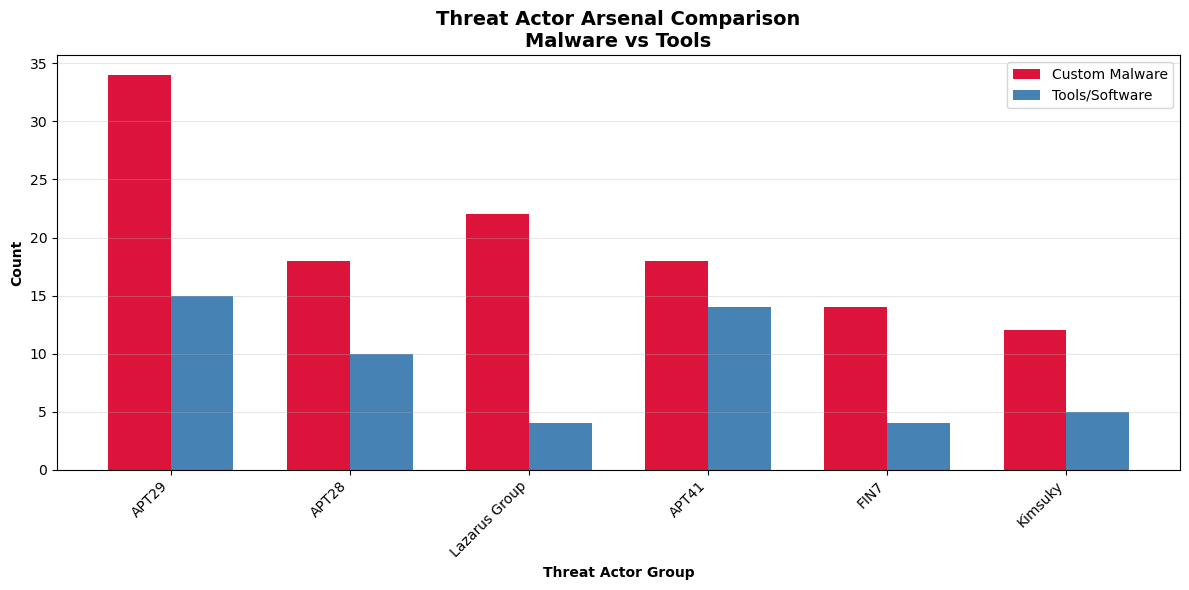

In [23]:
# Visualize the comparison
profiler.plot_arsenal_comparison(comparison_groups)

### [2.4] Shared Infrastructure Analysis

Identify which threat actors share malware or tools - potential operational connections.

In [24]:
# Find which groups share common tools
common_tools = ["Mimikatz", "Cobalt Strike", "PsExec"]

print("SHARED TOOL USAGE ANALYSIS")
print("="*50)

for tool in common_tools:
    groups = profiler.find_shared_malware(tool)
    
    if groups:
        print(f"\n{tool}:")
        print(f"  Used by {len(groups)} threat actors")
        print(f"  Groups: {', '.join(groups[:5])}")
        if len(groups) > 5:
            print(f"  ... and {len(groups) - 5} more")

SHARED TOOL USAGE ANALYSIS
[*] Finding groups that use Mimikatz...
[+] 52 groups use Mimikatz

Mimikatz:
  Used by 52 threat actors
  Groups: Indrik Spider, Medusa Group, Wizard Spider, FIN7, Dragonfly
  ... and 47 more
[*] Finding groups that use Cobalt Strike...
[+] 29 groups use Cobalt Strike

Cobalt Strike:
  Used by 29 threat actors
  Groups: Indrik Spider, LuminousMoth, Wizard Spider, FIN7, Aquatic Panda
  ... and 24 more
[*] Finding groups that use PsExec...
[+] 39 groups use PsExec

PsExec:
  Used by 39 threat actors
  Groups: Indrik Spider, Medusa Group, Wizard Spider, Dragonfly, OilRig
  ... and 34 more


### [2.5] Nation-State Arsenal Patterns

Compare arsenal composition by sponsoring nation-state.

In [25]:
# Compare arsenals by nation-state
nation_groups = {
    "Russia": ["APT28", "APT29", "Turla"],
    "China": ["APT1", "APT41"],
    "North Korea": ["Lazarus Group", "APT38"],
    "Iran": ["APT33", "MuddyWater", "APT34"]
}

print("NATION-STATE ARSENAL ANALYSIS")
print("="*80)

for nation, groups in nation_groups.items():
    print(f"\n{nation}:")
    
    total_malware = 0
    total_tools = 0
    
    for group in groups:
        malware = profiler.get_group_malware(group)
        tools = profiler.get_group_tools(group)
        total_malware += len(malware)
        total_tools += len(tools)
        
        if not malware.empty or not tools.empty:
            print(f"  {group}: {len(malware)} malware, {len(tools)} tools")
    
    print(f"  TOTAL: {total_malware} malware families, {total_tools} tools")

NATION-STATE ARSENAL ANALYSIS

Russia:
  APT28: 18 malware, 10 tools
  APT29: 34 malware, 15 tools
  Turla: 17 malware, 13 tools
  TOTAL: 69 malware families, 38 tools

China:
  APT1: 6 malware, 11 tools
  APT41: 18 malware, 14 tools
  TOTAL: 24 malware families, 25 tools

North Korea:
  Lazarus Group: 22 malware, 4 tools
  APT38: 4 malware, 2 tools
  TOTAL: 26 malware families, 6 tools

Iran:
  APT33: 7 malware, 9 tools
  MuddyWater: 6 malware, 9 tools
  APT34: 18 malware, 12 tools
  TOTAL: 31 malware families, 30 tools


### [2.5] Sophistication Analysis 

Measures operational maturity across threat actors using technique count and cluster placement as proxy indicators for program capability. The three visualizations below examine how groups distribute across capability tiers, how cluster compositions break down by operational profile, and which actors demonstrate the most extensively documented TTP portfolios. Together they reveal that sophistication is not evenly distributed — a small subset of elite actors accounts for the majority of documented offensive capability across the threat landscape.


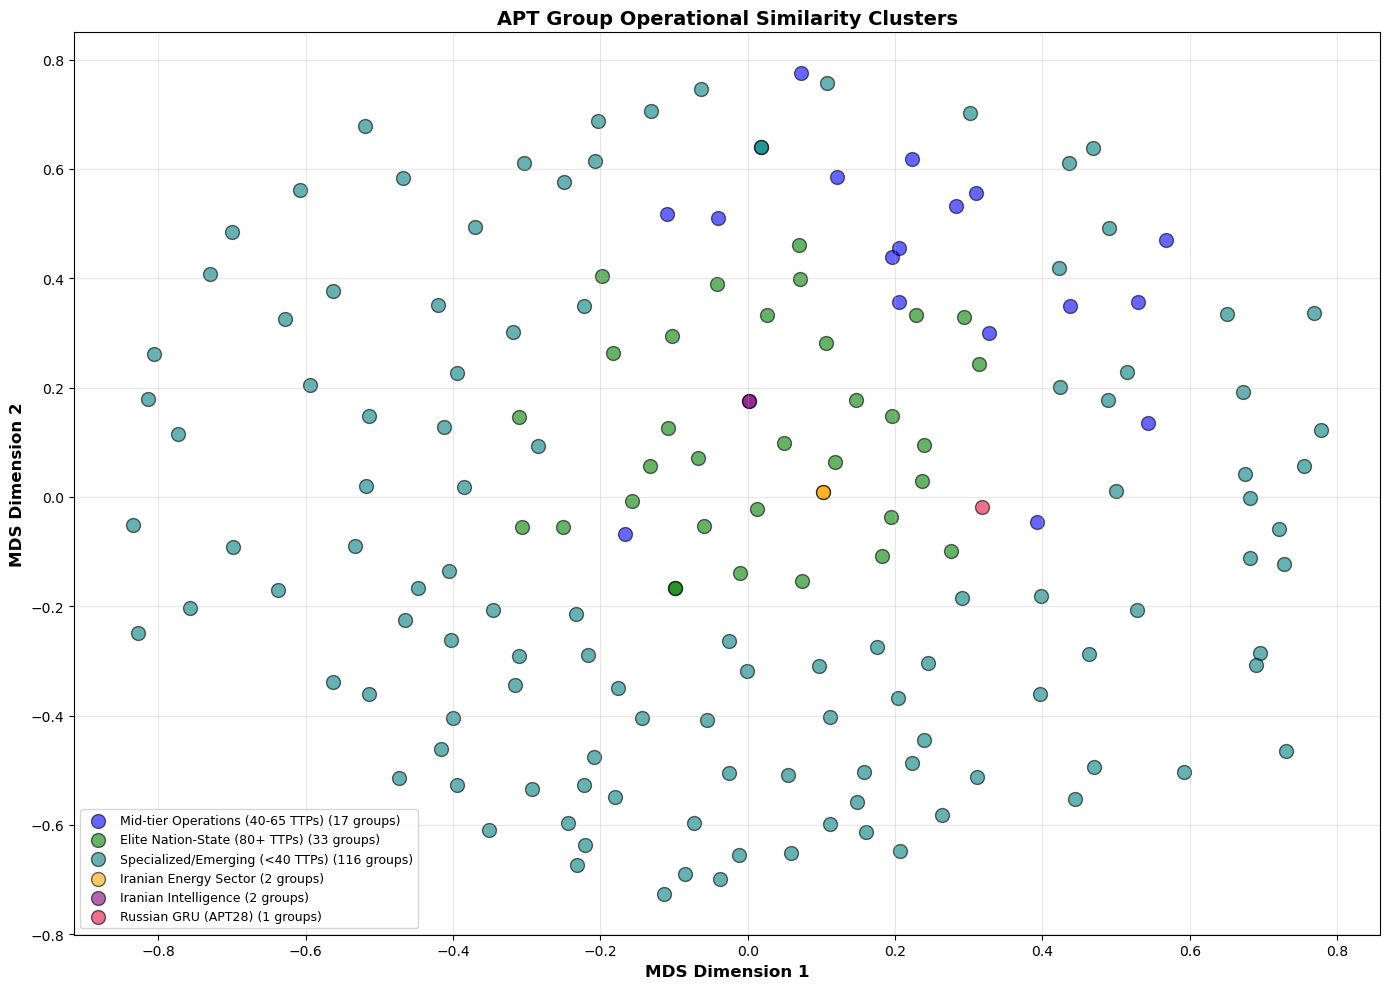

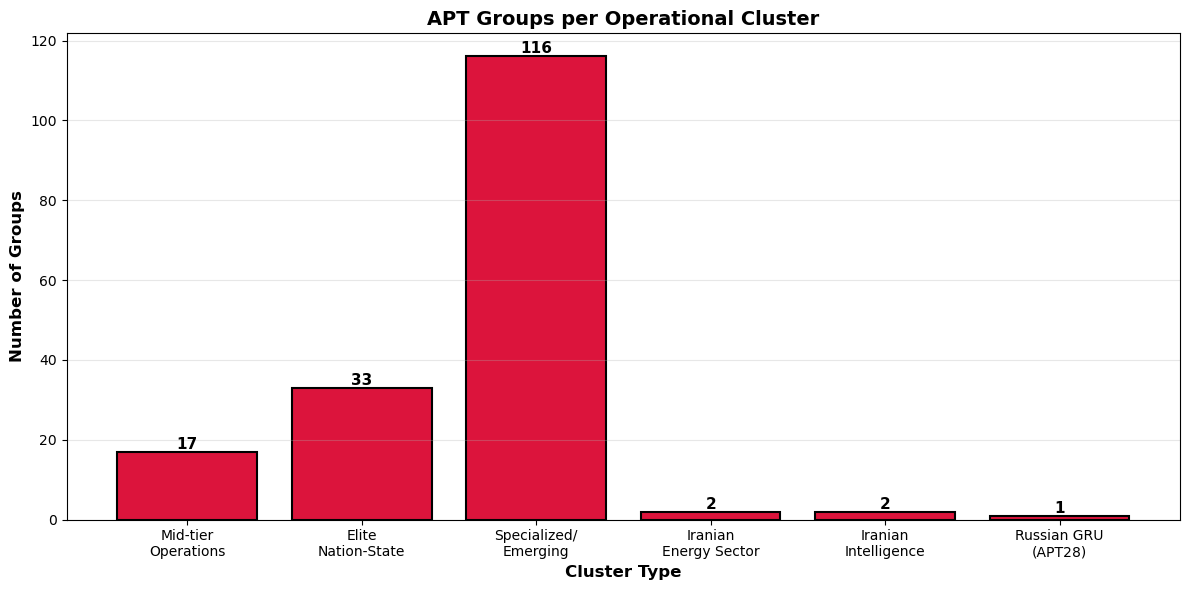

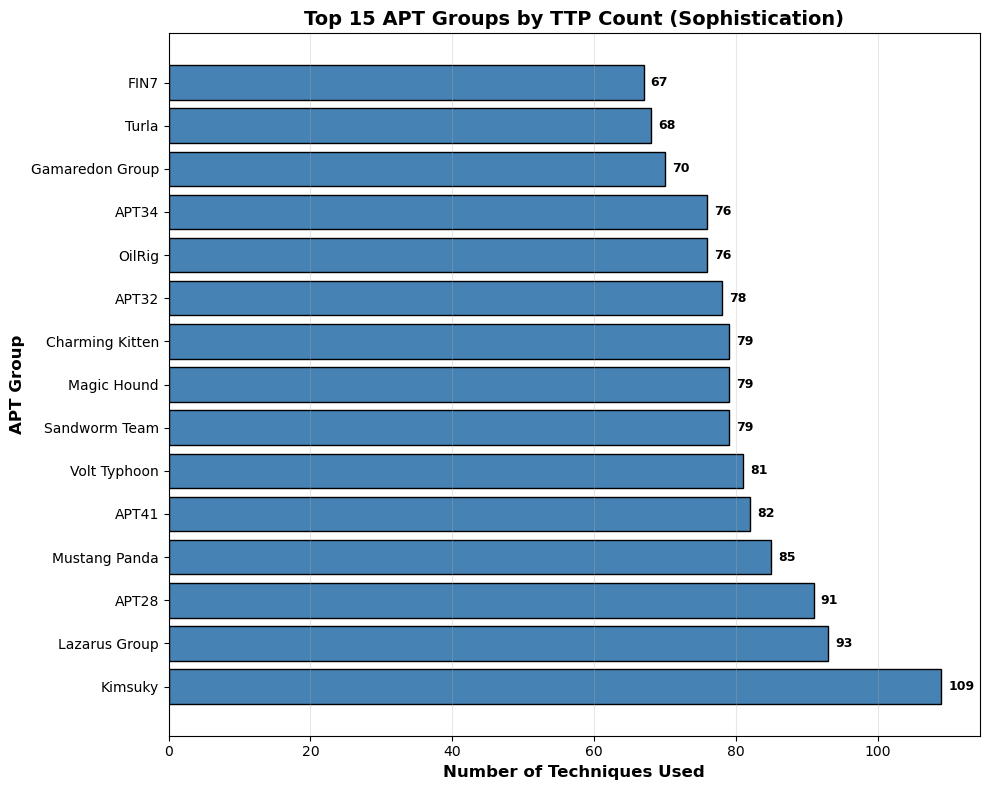

In [26]:
from sklearn.manifold import MDS
import matplotlib.pyplot as plt

# MDS calculation
mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42)
distance_matrix = 1 - similarity_matrix
coords = mds.fit_transform(distance_matrix)

#Visualization 1 APT Simularity Cluster
fig, ax = plt.subplots(figsize=(14, 10))
cluster_colors = {0: 'blue', 1: 'green', 2: 'teal', 3: 'orange', 4: 'purple', 5: 'crimson'}
#Descriptive cluster labels
cluster_labels = {
    0: "Mid-tier Operations (40-65 TTPs)",
    1: "Elite Nation-State (80+ TTPs)",
    2: "Specialized/Emerging (<40 TTPs)",
    3: "Iranian Energy Sector",
    4: "Iranian Intelligence",
    5: "Russian GRU (APT28)"
}
#Plot in order
for cluster_id in [0, 1, 2, 3, 4, 5]:
    mask = cluster_results['cluster'] == cluster_id
    cluster_data = cluster_results[mask]
    
    if len(cluster_data) > 0:
        indices = [list(similarity_matrix.index).index(g) for g in cluster_data['group']]
        
        ax.scatter(coords[indices, 0], coords[indices, 1], 
                  c=cluster_colors.get(cluster_id),
                  label=f'{cluster_labels[cluster_id]} ({len(cluster_data)} groups)',
                  s=100, alpha=0.6, edgecolors='black', linewidth=1)
ax.set_xlabel('MDS Dimension 1', fontweight='bold', fontsize=12)
ax.set_ylabel('MDS Dimension 2', fontweight='bold', fontsize=12)
ax.set_title('APT Group Operational Similarity Clusters', fontweight='bold', fontsize=14)
ax.legend(loc='best', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

######
cluster_counts = cluster_results['cluster'].value_counts().sort_index()
#Descriptive labels
cluster_labels = {
    0: "Mid-tier\nOperations",
    1: "Elite\nNation-State",
    2: "Specialized/\nEmerging",
    3: "Iranian\nEnergy Sector",
    4: "Iranian\nIntelligence",
    5: "Russian GRU\n(APT28)"
}

#Visualization 2: APT groups per cluster 
fig, ax = plt.subplots(figsize=(12, 6))
x_labels = [cluster_labels[i] for i in cluster_counts.index]
bars = ax.bar(range(len(cluster_counts)), cluster_counts.values, 
              color='crimson', edgecolor='black', linewidth=1.5)
ax.set_xlabel('Cluster Type', fontweight='bold', fontsize=12)
ax.set_ylabel('Number of Groups', fontweight='bold', fontsize=12)
ax.set_title('APT Groups per Operational Cluster', fontweight='bold', fontsize=14)
ax.set_xticks(range(len(cluster_counts)))
ax.set_xticklabels(x_labels, fontsize=10)
ax.grid(axis='y', alpha=0.3)
# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
           f'{int(height)}',
           ha='center', va='bottom', fontweight='bold', fontsize=11)
plt.tight_layout()
plt.show()

#Visualization 3: Top APTs by sophistication 
top_15 = cluster_results.nlargest(15, 'num_techniques')
fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(range(len(top_15)), top_15['num_techniques'].values, 
               color='steelblue', edgecolor='black', linewidth=1)
ax.set_yticks(range(len(top_15)))
ax.set_yticklabels(top_15['group'].values)
ax.set_xlabel('Number of Techniques Used', fontweight='bold', fontsize=12)
ax.set_ylabel('APT Group', fontweight='bold', fontsize=12)
ax.set_title('Top 15 APT Groups by TTP Count (Sophistication)', 
             fontweight='bold', fontsize=14)
ax.grid(axis='x', alpha=0.3)
#value labels
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width + 1, bar.get_y() + bar.get_height()/2,
           f'{int(width)}',
           ha='left', va='center', fontweight='bold', fontsize=9)
plt.tight_layout()
plt.show()


### [2.5.1] Sophistication Analysis -- Key Insights

**Top Tier Operations (80+ techniques):**
- Kimsuky (109): North Korean intelligence, most extensively documented APT
- Lazarus Group (93): NK elite unit, financial + espionage dual mandate
- APT28 (91): Russian GRU military intelligence
- Mustang Panda (85): Chinese government/NGO targeting
- APT41 (82): Chinese dual use actor (espionage + cybercrime)

**Cluster Key:**
- Cluster 0: Mid tier operations (40-65 techniques)
- Cluster 1: Elite nation state (80+ techniques)
- Cluster 2: Specialized/emerging (<40 techniques)
- Cluster 3: Iranian energy sector specialists
- Cluster 4: Iranian intelligence operations
- Cluster 5: Russian GRU (APT28)

**Cluster Distribution Assessment:**

Cluster 1 (33 groups) represents elite nation state operations with 80+ techniques, including top tier APTs demonstrating extensive capabilities and operational flexibility. Cluster 0 (17 groups) contains mid tier professional operations mixing state sponsored and cybercrime actors. Cluster 2 (116 groups, 68% of dataset) encompasses specialized operations with focused TTP sets, indicating most tracked APT activity involves narrow operational mandates rather than broad spectrum attacks. Outlier clusters 3, 4, and 5 (5 groups total) demonstrate unique operational signatures reflecting Iranian energy sector focus, Iranian intelligence collection, and APT28's distinct Russian GRU tradecraft respectively.

**Operational Patterns:**

Elite actors in Cluster 1 share operational space regardless of nation state sponsor. North Korean, Russian, and Chinese groups cluster together when possessing similar TTP portfolios, demonstrating that capability breadth is a stronger organizing principle than national origin. Cluster 2's dispersion reflects the diversity of specialized actors across the threat landscape. Isolated clusters reveal groups whose unique tradecraft requires tailored detection strategies.

**Assessment:**

North Korean groups dominate top tier rankings (Kimsuky #1, Lazarus #2) despite resource constraints, demonstrating strategic cyber investment. Iranian rapid maturation is evident through four groups in the top 15. Cluster 1 actors represent 19% of tracked groups but likely account for the majority of strategic intelligence collection operations globally.

**Defensive Priority:** Cluster 1 requires comprehensive detection coverage due to operational breadth. Cluster 2 may be addressed with campaign specific or sector focused defenses. Outlier clusters warrant specialized detection strategies given their distinct operational signatures.

# [III] Data Export Framework ───────────────

This section exports all analysis outputs to structured CSV files for downstream use in threat hunting workflows, SIEM integration, or further analysis. Outputs are organized into raw, processed, and summaries subdirectories with timestamps to prevent overwriting across sessions. A metadata file and data dictionary are generated alongside each export run to document the parameters and structure of every output file.


In [27]:
#Export all analysis results
profiler.export_data(prefix='outputs/threat_analysis')

[*] Exporting analysis data with timestamp: 20260330_213659
[+] TTP Matrix: outputs/raw/threat_analysis_ttp_matrix_20260330_213659.csv
[+] Similarity Matrix: outputs/processed/threat_analysis_similarity_20260330_213659.csv
[+] Enhanced Groups DB: outputs/processed/threat_analysis_groups_enhanced_20260330_213659.csv
[*] Extracting malware families...
[+] Found 696 malware families
[*] Extracting tools and software...
[+] Found 91 tools
[+] Summary Statistics: outputs/summaries/threat_analysis_summary_20260330_213659.csv
[+] Metadata: outputs/metadata_20260330_213659.json
[+] Data Dictionary: outputs/DATA_DICTIONARY.txt

[+] Export complete - 6 files generated


In [28]:
print("Exporting Phase 2 arsenal data...")

# Export arsenal comparison
arsenal_comparison.to_csv('outputs/arsenal_comparison.csv')
print("[+] Saved arsenal comparison to outputs/")

# Export individual arsenal for target group
if enhanced_profile and 'arsenal' in enhanced_profile:
    if not enhanced_profile['arsenal'].empty:
        enhanced_profile['arsenal'].to_csv(f'outputs/{target_group}_arsenal.csv', index=False)
        print(f"[+] Saved {target_group} arsenal to outputs")


Exporting Phase 2 arsenal data...
[+] Saved arsenal comparison to outputs/
[+] Saved APT34 arsenal to outputs


## [3.1] Exported 

**Exported Files:**
- `raw/threat_analysis_ttp_matrix_[timestamp].csv` — Binary feature matrix (groups × techniques)
- `processed/threat_analysis_similarity_[timestamp].csv` — Cosine similarity scores rounded to 3 decimals
- `processed/threat_analysis_groups_enhanced_[timestamp].csv` — Complete groups database with technique counts and arsenal metrics
- `summaries/threat_analysis_summary_[timestamp].csv` — Key statistics and dataset overview
- `metadata_[timestamp].json` — Export parameters and MITRE source version
- `DATA_DICTIONARY.txt` — Documentation for all output files and column definitions

## [IV] Sector Targeting Analysis ───────────

This section maps threat actors to targeted industries by scanning MITRE group descriptions for sector specific keywords across 10 verticals: Government, Energy, Finance, Healthcare, Technology, Defense, Manufacturing, Education, Media, and NGO. The analysis reveals which industries face the highest threat actor density and how targeting priorities differ across nation state programs. Understanding sector targeting patterns allows defenders to contextualize risk based on their industry and prioritize detection coverage accordingly.

### [4.1]: Sector Distribution 

Scans MITRE ATT&CK group descriptions for industry-specific keywords across 10 verticals to identify which sectors each threat actor targets. The results are aggregated into a binary targeting matrix and cross-referenced with nation-state attribution to reveal how different programs prioritize their operational objectives. Rather than relying on manually curated threat reports, this approach extracts targeting intelligence directly from structured MITRE data at scale across all 187 tracked groups.

[*] Extracting sector targeting data...
[+] Sector targeting extracted for 187 groups


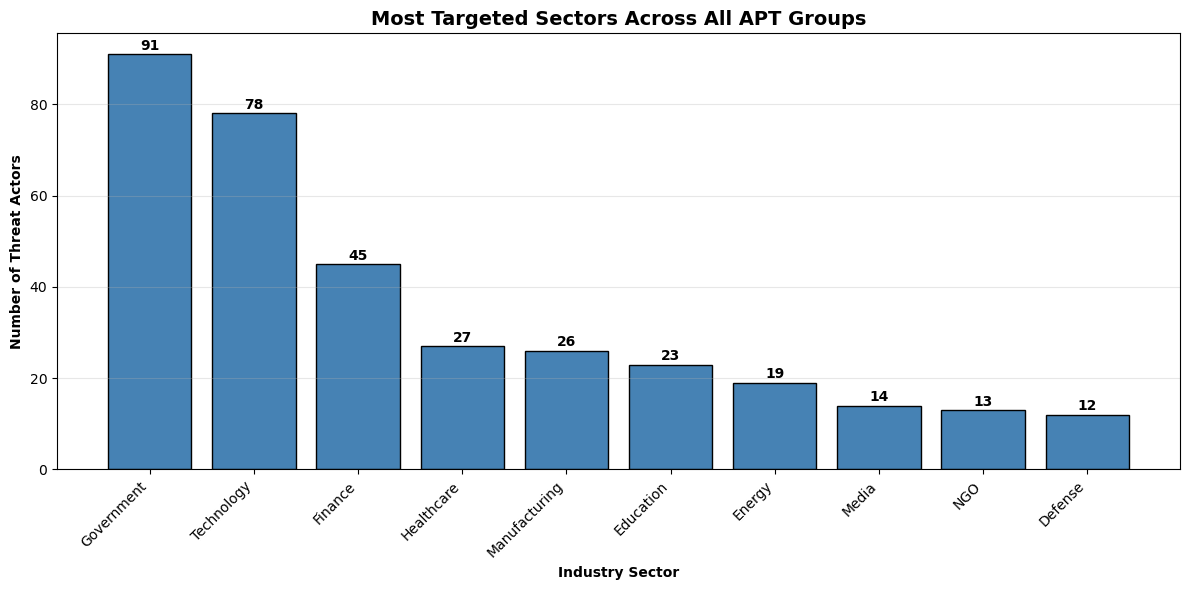

In [29]:
# Most targeted sectors across all APT groups
profiler.plot_sector_distribution()

[*] Extracting sector targeting data...
[+] Sector targeting extracted for 187 groups


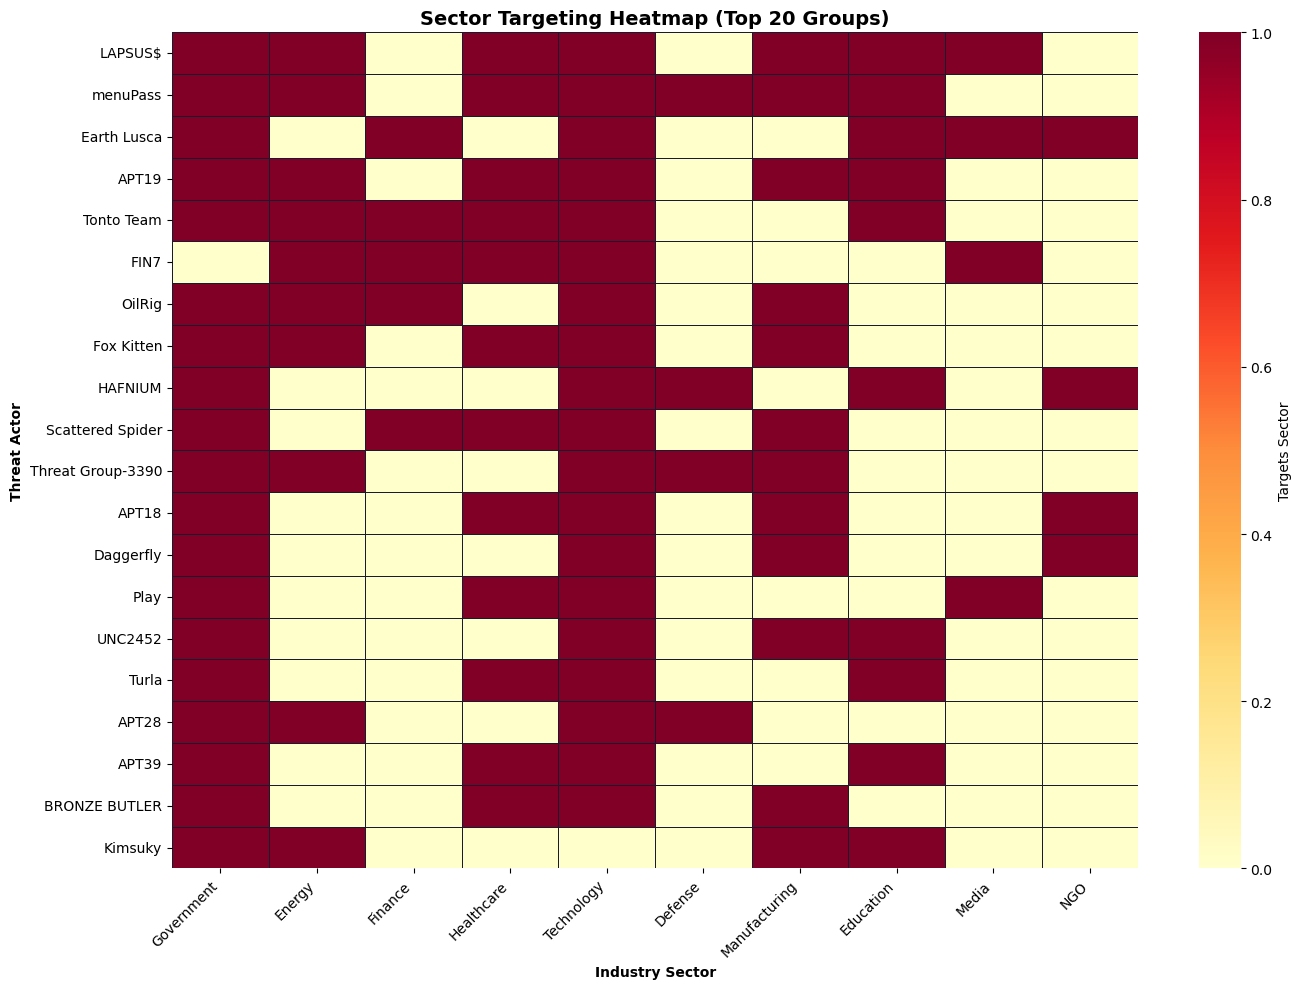

In [30]:
#Which groups target which sectors
profiler.plot_sector_targeting_heatmap(top_n=20)

In [31]:
# Cross-reference nation-states with sector targeting
sector_results = profiler.nation_state_sector_analysis()

[*] Extracting sector targeting data...
[+] Sector targeting extracted for 187 groups

NATION-STATE SECTOR TARGETING ANALYSIS

Russia:
  Government: 7 group(s)
  Technology: 5 group(s)
  Education: 3 group(s)
  Defense: 2 group(s)
  Energy: 1 group(s)
  Healthcare: 1 group(s)
  NGO: 1 group(s)
  Manufacturing: 1 group(s)

China:
  Government: 9 group(s)
  Technology: 8 group(s)
  Education: 6 group(s)
  Finance: 4 group(s)
  Healthcare: 3 group(s)
  NGO: 3 group(s)
  Energy: 3 group(s)
  Defense: 3 group(s)
  Manufacturing: 2 group(s)
  Media: 1 group(s)

North Korea:
  Finance: 4 group(s)
  Government: 2 group(s)
  Media: 1 group(s)
  Energy: 1 group(s)
  Manufacturing: 1 group(s)
  Education: 1 group(s)
  NGO: 1 group(s)
  Technology: 1 group(s)

Iran:
  Government: 6 group(s)
  Energy: 4 group(s)
  Technology: 4 group(s)
  Education: 3 group(s)
  Healthcare: 3 group(s)
  Manufacturing: 2 group(s)
  Finance: 1 group(s)
  Media: 1 group(s)
  NGO: 1 group(s)




### [4.1.1] Sector & Victim Targeting Analysis

**Government sector leads with 91 threat actors targeting it** — the most targeted sector by a significant margin, reflecting the universal strategic value of government intelligence across all nation-state programs. In the current geopolitical environment, this is unsurprising: state secrets, policy decisions, and diplomatic communications represent the highest-value intelligence targets.

**Technology sector (78 groups)** ranks second, consistent with nation-state interest in intellectual property theft, supply chain compromise, and telecommunications infrastructure access.

**Finance sector (45 groups)** reflects both espionage objectives and North Korea's documented use of cyber operations for revenue generation under international sanctions — 3 of 5 tracked DPRK groups target financial institutions.

---

### [4.1.2] Nation-State Operational Priorities

**Russia** concentrates on Government (3), Technology (2), and Education (2) — consistent with SVR/GRU intelligence collection mandates targeting policy institutions and research organizations.

**China** demonstrates the broadest targeting spread across 9 sectors, with Government (5) and Education (4) leading — reflecting a wide-ranging espionage mandate that extends into academic and research institutions for long-term technology acquisition.

**North Korea** shows a distinct Finance (3) concentration absent in other nation-state programs — a direct indicator of DPRK's cyber-enabled sanctions evasion strategy. Government (2) and Manufacturing (1) targeting suggests secondary intelligence collection objectives alongside revenue generation.

**Iran** leads in Energy sector targeting (3 groups) — the only nation-state program where Energy rivals Government as a primary target. This aligns with documented campaigns against regional oil, gas, and petrochemical infrastructure, reflecting geopolitical leverage objectives and economic competition in the Gulf region.

---

### [4.1.3] Heatmap Observations

Groups like LAPSUS$, menuPass, and Earth Lusca demonstrate broad multi-sector targeting, indicating opportunistic or wide-mandate operations. In contrast, FIN7's near-exclusive Finance focus and Kimsuky's Government concentration reflect specialized operational mandates with narrow but deep domain expertise.

**Defensive Priority:** Organizations in Government, Technology, and Finance face the highest threat actor density and should prioritize detection coverage accordingly. Energy sector defenders should specifically account for Iranian actor TTPs given their concentrated targeting of that vertical.

## [4.2] Network Graph - Infrastructure Sharing Analysis

Visualizes threat actor relationships based on shared malware and tools. Nodes represent threat actors sized by technique count, edges connect groups sharing two or more arsenal items. Reveals potential infrastructure connections, shared development resources, or common operational toolkits across the threat landscape.

[*] Building malware sharing network (min_shared=2)...
[+] Network: 161 nodes, 1184 edges


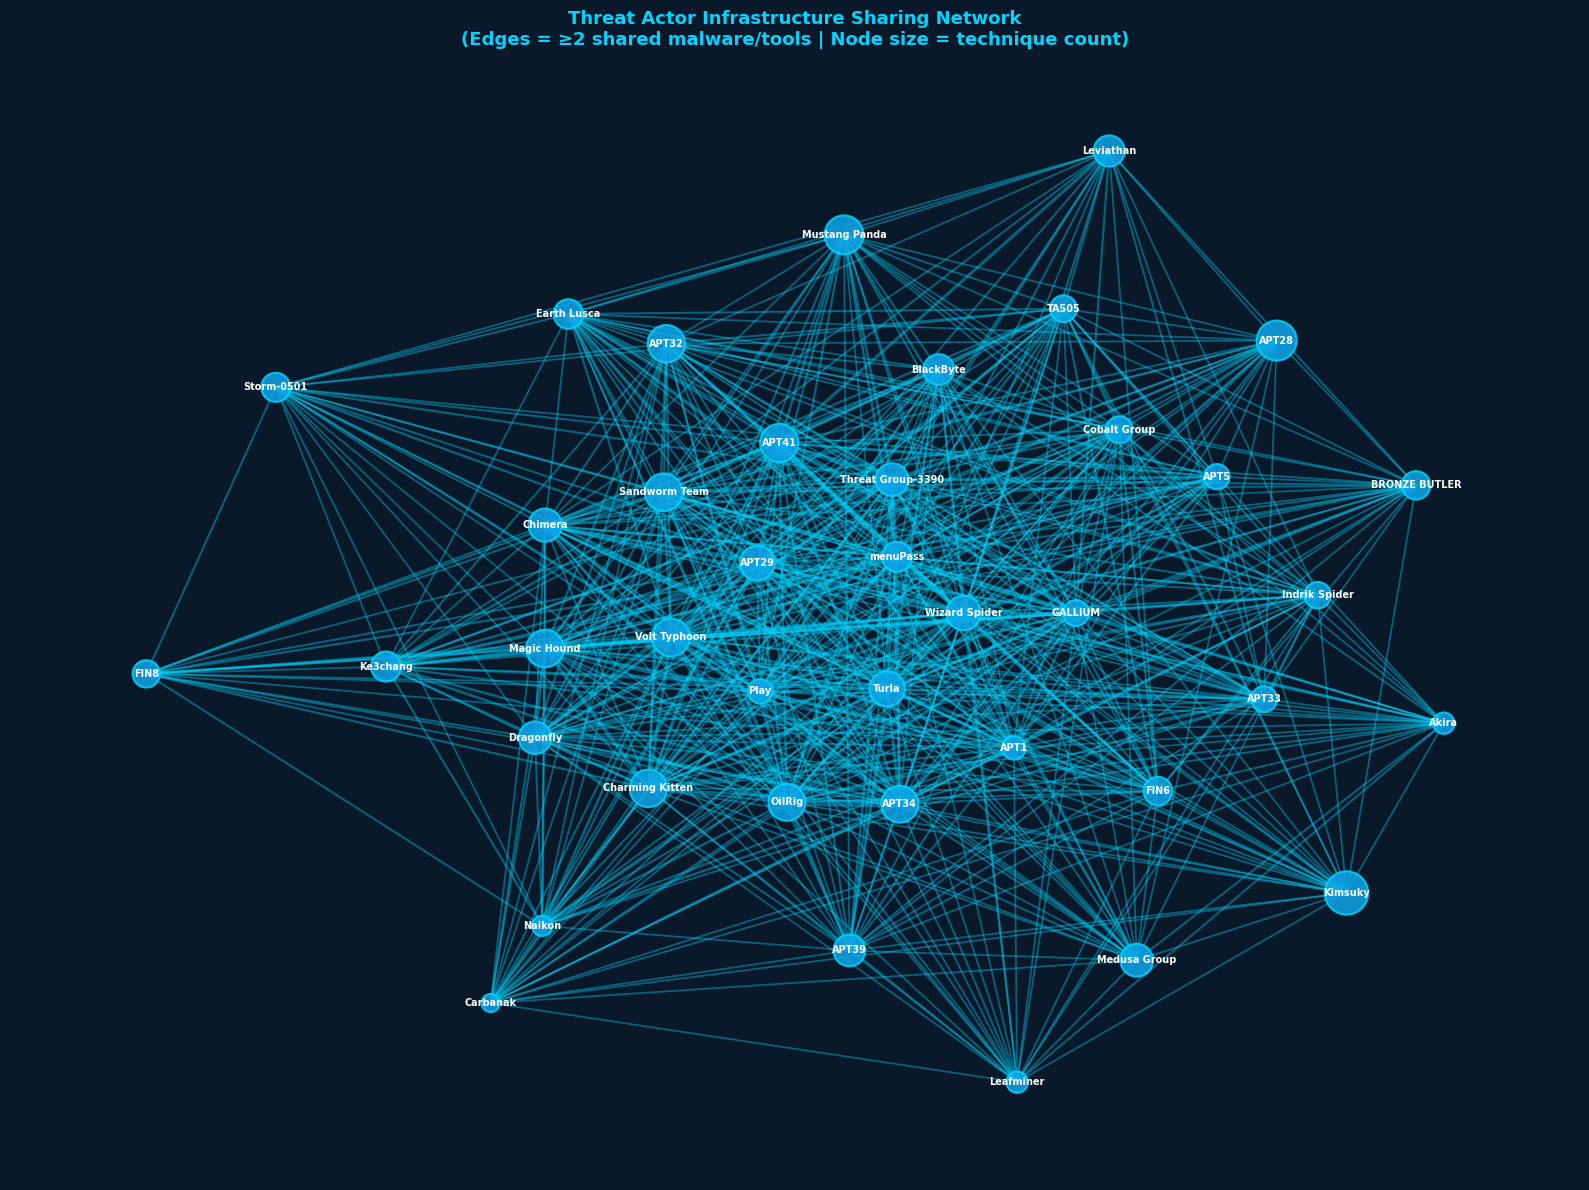

[*] Building malware sharing network (min_shared=2)...
[+] Network: 161 nodes, 1184 edges
Total connected groups: 161
Total sharing relationships: 1184

Most connected threat actors:
  menuPass: 69 connections
  APT41: 66 connections
  GALLIUM: 61 connections
  Threat Group-3390: 61 connections
  APT29: 60 connections
  Wizard Spider: 59 connections
  Sandworm Team: 58 connections
  Turla: 57 connections
  Volt Typhoon: 57 connections
  OilRig: 54 connections


In [32]:
# Build and visualize malware sharing network
profiler.plot_malware_network(min_shared=2, top_n=40)

# And network statistics
G = profiler.build_malware_network(min_shared=2)
print(f"Total connected groups: {G.number_of_nodes()}")
print(f"Total sharing relationships: {G.number_of_edges()}")

import networkx as nx
print(f"\nMost connected threat actors:")
degrees = sorted(G.degree(), key=lambda x: x[1], reverse=True)[:10]
for group, degree in degrees:
    print(f"  {group}: {degree} connections")

### [4.2.1] Network Analysis Findings

**menuPass (69) and APT41 (66)** lead in infrastructure connections, with GALLIUM and Threat Group-3390 closely behind — all Chinese-attributed actors. This concentration suggests either shared development resources within Chinese cyber programs or common adoption of the same commodity tools across independently operated groups.

**APT29 (60)** ranking fifth despite being a highly specialized Russian SVR unit reflects the breadth of its documented toolkit rather than indiscriminate tool sharing — consistent with its reputation as one of the most technically sophisticated APT groups.

**Wizard Spider (59)** as a non-state ransomware actor appearing in the top 10 highlights how commodity offensive tools blur the line between nation-state and criminal infrastructure. Groups like Cobalt Strike and Mimikatz create natural connectivity across otherwise unrelated threat actors.

**Note:** High connection count indicates shared arsenal items but does not necessarily imply operational coordination. Commodity tools (Mimikatz, Cobalt Strike, PsExec) are widely adopted and will naturally inflate connectivity scores.

## [4.3] Predictive Attribution Model

Trains a Random Forest classifier on the TTP matrix to predict threat actor identity from observed techniques. Given a set of observed technique IDs from an unknown attack, the model returns ranked threat actors with confidence scores.

**Methodology:**
- Features: Binary TTP matrix (groups × techniques)
- Algorithm: Random Forest (200 estimators, balanced class weights)
- Training: 80/20 train/test split on groups with 5+ documented techniques
- Output: Ranked attribution candidates with probability scores

In [33]:
# Train attribution classifier
clf, le, acc = profiler.train_attribution_model()

# Test with APT29-like techniques (Russian SVR)
observed_ttps = [
    'T1566.001',  # Spearphishing Attachment
    'T1059.001',  # PowerShell
    'T1003.001',  # LSASS Memory
    'T1078',      # Valid Accounts
    'T1027',      # Obfuscated Files
    'T1071.001',  # Web Protocols C2
    'T1105',      # Ingress Tool Transfer
    'T1547.001'   # Registry Run Keys
]

results = profiler.predict_threat_actor(observed_ttps)
print(results)

[*] Training nation-state attribution classifier...
[+] Training samples: 36
[+] Nation-state classes: [np.str_('China'), np.str_('Iran'), np.str_('North Korea'), np.str_('Russia')]
[+] Test accuracy: 50.00%

[+] Classification Report:
              precision    recall  f1-score   support

       China       0.43      1.00      0.60         3
        Iran       1.00      0.33      0.50         3
 North Korea       0.00      0.00      0.00         2

    accuracy                           0.50         8
   macro avg       0.48      0.44      0.37         8
weighted avg       0.54      0.50      0.41         8

[*] Training nation-state attribution classifier...
[+] Training samples: 36
[+] Nation-state classes: [np.str_('China'), np.str_('Iran'), np.str_('North Korea'), np.str_('Russia')]
[+] Test accuracy: 50.00%

[+] Classification Report:
              precision    recall  f1-score   support

       China       0.43      1.00      0.60         3
        Iran       1.00      0.33     

### [4.3.1] Attribution Model Assessment

**Performance:** The classifier achieves 50% accuracy across four nation state classes, double random chance (25%) with 36 labeled training samples. Iran demonstrates the strongest signal with 1.0 precision, meaning every Iran prediction was correct. North Korea scores 0.00 across all metrics, proving the most difficult to classify due to documented TTP overlap with Chinese actors.

**An Unexpected Finding:** The assumption going in was that nation state actors would have sufficiently distinct TTP signatures to make classification straightforward. The results tell a more nuanced story. The model returning 84% confidence for China on a set of known Russian SVR techniques is not simply a misclassification — it reflects genuine operational overlap between these programs at the TTP level. More notably, the model's inability to distinguish North Korea from China aligns with documented cases of misattribution between DPRK and Chinese actors in the threat intelligence community. The classifier is surfacing a real analytical challenge, not just a dataset problem.

**What the Feature Importance Reveals:** The most diagnostic techniques for nation state attribution are not the most commonly used ones. They are the rare, specialized techniques that appear almost exclusively within one program. This is where the real attribution signal lives and it points toward a more targeted detection engineering approach: prioritize detection of low frequency, high specificity techniques over broad TTP coverage.

**Limitation:** With 36 training samples across 4 classes, this model is a proof of concept. The test set of 8 samples is too small for statistically reliable evaluation. Scaling the labeled dataset and incorporating additional intelligence dimensions such as infrastructure patterns, victimology, and campaign timing would significantly improve both accuracy and confidence in attribution outputs.

---

## Project Reflections

Building this project taught me that Python is far more involved than coursework suggests — the gap between writing code that runs and writing code that actually works reliably in production is significant. Managing module imports, kernel state, caching behavior, and indentation across a multi-phase project gave me a practical education that no assignment could replicate.

The finding that surprised me most was North Korea. Going in, I assumed the most resourced nation-state programs would dominate every metric. Instead, Lazarus Group and Kimsuky consistently outperformed expectations — more documented techniques, higher connectivity in the infrastructure network, and a malware-heavy arsenal despite operating under severe resource constraints and international sanctions. The DPRK cyber program essentially does more with less, which from an intelligence perspective makes them one of the most analytically interesting actors to track.

The APT branching relationships were also unexpected. Seeing how threat actors cluster and share operational DNA — almost like subsidiary groups spinning off from larger programs — reframed how I think about attribution. It is less about identifying a single group and more about understanding an ecosystem of related actors with shared tradecraft, resources, and objectives.

On what I would do differently: the Streamlit dashboard never fully integrated the arsenal analysis due to a module caching conflict that proved difficult to resolve cleanly. In hindsight, structuring the application with a more deliberate module loading strategy from the start would have avoided the workaround entirely. I also underestimated the importance of metadata early on — structuring exports with timestamps, data dictionaries, and version tracking from the beginning would have saved significant rework later in the project.

This was my first deep dive into threat intelligence and the CTI community, and it reinforced that this is the intersection I want to work in — OSINT methodology, adversary analysis, and machine learning applied to real intelligence problems.

---

*To see more of my OSINT and CTI work, visit my repository: https://github.com/Edi-San24/threat-actor-profiler* 
